# RegimeLens MVP

**An Explainable AI Prototype for Single-Asset Market Regime Detection**

This notebook demonstrates a simple MVP for RegimeLens using historical **AAPL** data. The goal is to detect interpretable market regimes from technical indicators rather than predict future prices.

**Dataset source:** Plotly public sample dataset (`finance-charts-apple.csv`)

Source URL: https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("default")

## 2. Load the local dataset
The notebook uses the submitted `dataset.csv` so the demo can run without downloading new data during the presentation.

In [2]:
dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path, parse_dates=['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,Adjusted,AssetSymbol,DataSource
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,AAPL,https://raw.githubusercontent.com/plotly/datas...
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,AAPL,https://raw.githubusercontent.com/plotly/datas...
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,AAPL,https://raw.githubusercontent.com/plotly/datas...
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,AAPL,https://raw.githubusercontent.com/plotly/datas...
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,AAPL,https://raw.githubusercontent.com/plotly/datas...


## 3. Basic data checks

In [3]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Missing values by column:')
print(df.isna().sum())

Shape: (506, 9)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted', 'AssetSymbol', 'DataSource']
Missing values by column:
Date           0
Open           0
High           0
Low            0
Close          0
Volume         0
Adjusted       0
AssetSymbol    0
DataSource     0
dtype: int64


## 4. Keep core market columns and clean data

In [4]:
market = df[['Date','Open','High','Low','Close','Volume','Adjusted','AssetSymbol','DataSource']].copy()
market = market.sort_values('Date').drop_duplicates().reset_index(drop=True)
market.head()

,Date,Open,High,Low,Close,Volume,Adjusted,AssetSymbol,DataSource
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,AAPL,https://raw.githubusercontent.com/plotly/datas...
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,AAPL,https://raw.githubusercontent.com/plotly/datas...
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,AAPL,https://raw.githubusercontent.com/plotly/datas...
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,AAPL,https://raw.githubusercontent.com/plotly/datas...
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,AAPL,https://raw.githubusercontent.com/plotly/datas...


## 5. Feature engineering
We create a small, interpretable feature set for regime detection: daily return, 20-day moving average, 20-day annualized volatility, RSI(14), and price distance from MA20.

In [5]:
market['Return'] = market['Adjusted'].pct_change()
market['MA20'] = market['Adjusted'].rolling(20).mean()
market['Volatility20'] = market['Return'].rolling(20).std() * np.sqrt(252)

delta = market['Adjusted'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
market['RSI14'] = 100 - (100 / (1 + rs))
market['Close_vs_MA20'] = market['Adjusted'] / market['MA20'] - 1

feature_cols = ['Return', 'Volatility20', 'RSI14', 'Close_vs_MA20']
model_df = market.dropna(subset=feature_cols).copy()
model_df[feature_cols].head()

,Return,Volatility20,RSI14,Close_vs_MA20
20,0.016727,0.225314,45.533451,-0.004946
21,0.011256,0.227632,44.971638,0.006353
22,-0.007550,0.229116,47.391287,-0.000874
23,-0.012549,0.230786,41.765631,-0.012018
24,0.010405,0.210357,44.732969,0.000535


## 6. Cluster the data into 3 regimes using KMeans

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(model_df[feature_cols])

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
model_df['Cluster'] = kmeans.fit_predict(X)

model_df[['Date', 'Adjusted', 'Cluster']].head()

,Date,Adjusted,Cluster
20,2015-03-17,122.145688,1
21,2015-03-18,123.520597,0
22,2015-03-19,122.587966,1
23,2015-03-20,121.049608,1
24,2015-03-23,122.309137,1


## 7. Summarize each cluster and convert it into a human-readable regime

In [ ]:
# ------------------------------------------------------------
# Cluster Interpretation Layer (Explainability)
# ------------------------------------------------------------
# KMeans clustering assigns each observation to a cluster (0, 1, 2),
# but these numeric labels have no inherent meaning.
#
# This section converts raw clusters into human-readable market regimes
# by analyzing the average characteristics of each cluster.
#
# Steps:
# 1. Compute summary statistics (mean values) for each cluster
# 2. Define rule-based conditions using financial intuition
# 3. Assign a regime name and explanation to each cluster
# 4. Map the interpreted labels back to the original dataset
#
# This transforms the model output into an interpretable result,
# which is essential for the RegimeLens objective of explainability.
# ------------------------------------------------------------

# Compute average feature values for each cluster
# This summarizes the typical behavior of each market regime
cluster_summary = model_df.groupby('Cluster')[feature_cols + ['Adjusted']].mean()

# Count number of observations in each cluster (for context)
cluster_summary['Count'] = model_df.groupby('Cluster').size()

# Initialize columns for human-readable labels
cluster_summary['RegimeName'] = ''
cluster_summary['Explanation'] = ''

# Iterate through each cluster and assign a regime based on rules
for idx, row in cluster_summary.iterrows():
    
    # Rule 1: Highest volatility cluster → Volatile Transition
    # High volatility often indicates unstable or transitional market conditions
    if row['Volatility20'] == cluster_summary['Volatility20'].max():
        name = 'Volatile Transition'
        explanation = 'Highest volatility cluster; conditions change quickly and momentum is mixed.'
    
    # Rule 2: Strong positive signals → Bullish Trend
    # Positive returns + RSI >= 50 + price above MA20 indicate upward momentum
    elif row['Return'] > 0 and row['RSI14'] >= 50 and row['Close_vs_MA20'] > 0:
        name = 'Bullish Trend'
        explanation = 'Positive returns with price above MA20 and stronger RSI suggest an upward trend.'
    
    # Rule 3: Remaining cluster → Weak / Bearish
    # Lower returns and weaker price position suggest softer or bearish conditions
    else:
        name = 'Weak / Bearish'
        explanation = 'Weaker returns and lower relative price vs. MA20 suggest softer or bearish conditions.'
    
    # Assign the interpreted label back to the summary table
    cluster_summary.loc[idx, 'RegimeName'] = name
    cluster_summary.loc[idx, 'Explanation'] = explanation

# Create mapping dictionaries from cluster index → regime label
name_map = cluster_summary['RegimeName'].to_dict()
exp_map = cluster_summary['Explanation'].to_dict()

# Map regime labels back to each row in the original dataset
# This converts numeric cluster IDs into interpretable outputs
model_df['RegimeName'] = model_df['Cluster'].map(name_map)
model_df['RegimeExplanation'] = model_df['Cluster'].map(exp_map)

# Display rounded summary for readability
cluster_summary.round(4)

,Return,Volatility20,RSI14,Close_vs_MA20,Adjusted,Count,RegimeName,Explanation
Cluster,,,,,,,,
0,0.0044,0.2019,68.7784,0.0310,112.8074,228,Bullish Trend,Positive returns with price above MA20 and str...
1,-0.0064,0.2131,36.0843,-0.0292,108.7742,199,Weak / Bearish,Weaker returns and lower relative price vs. MA...
2,0.0077,0.3866,47.3018,-0.0068,102.8885,59,Volatile Transition,Highest volatility cluster; conditions change ...


## 8. Visualize regimes on the price chart

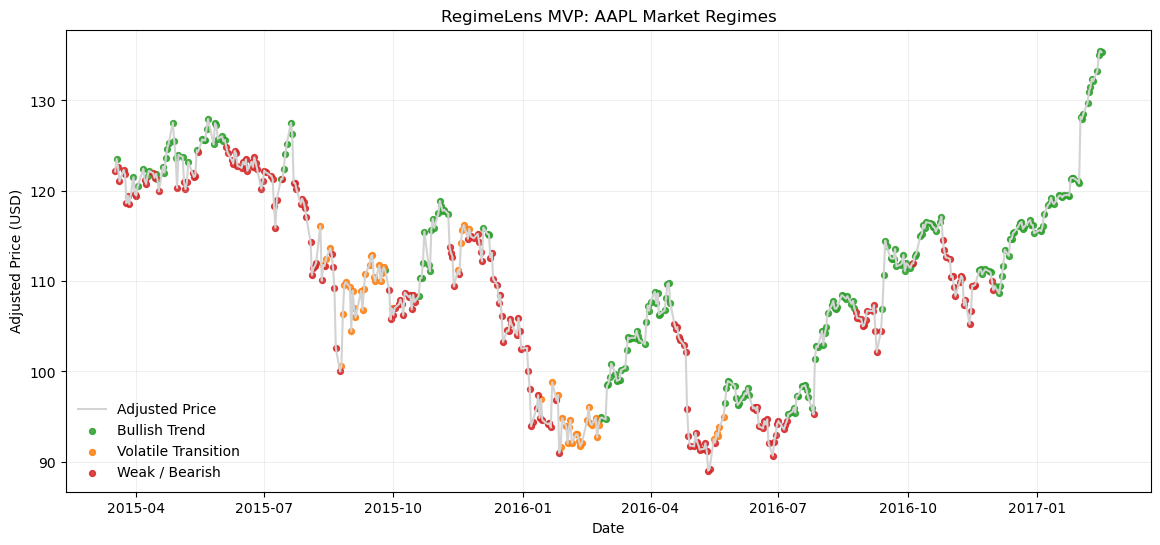

In [8]:
colors = {
    'Bullish Trend': '#2ca02c',
    'Weak / Bearish': '#d62728',
    'Volatile Transition': '#ff7f0e'
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(model_df['Date'], model_df['Adjusted'], color='lightgray', linewidth=1.5, label='Adjusted Price')

for regime, group in model_df.groupby('RegimeName'):
    ax.scatter(group['Date'], group['Adjusted'], s=18, alpha=0.85, label=regime, color=colors.get(regime))

ax.set_title('RegimeLens MVP: AAPL Market Regimes')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Price (USD)')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

## 9. Regime counts

In [9]:
model_df['RegimeName'].value_counts()

RegimeName
Bullish Trend          228
Weak / Bearish         199
Volatile Transition     59
Name: count, dtype: int64

## 10. Export final results

In [10]:
export_cols = ['Date','Open','High','Low','Close','Volume','Adjusted','AssetSymbol','DataSource'] + feature_cols + ['Cluster','RegimeName','RegimeExplanation']
final_results = model_df[export_cols].copy()
final_results.to_csv('regime_results.csv', index=False)
cluster_summary.reset_index().to_csv('regime_summary.csv', index=False)
print('Saved regime_results.csv and regime_summary.csv')

Saved regime_results.csv and regime_summary.csv


## 11. Conclusion
This MVP demonstrates the end-to-end idea behind RegimeLens:
- single-asset historical data analysis
- interpretable technical features
- unsupervised regime detection
- visual explanation through chart overlays and regime summaries

Future improvements could include multi-asset support, additional indicators, interactive filtering, and a lightweight web interface.